### 📡 Visualización de Datos Magnetotelúricos
---
**Curso:** Magnetotelúrica desde Cero: Fundamentos, Procesamiento e Interpretación de Datos  
**Módulo 3 — Análisis e Interpretación de Datos MT**

Este notebook introduce el flujo de trabajo básico para cargar y visualizar
datos magnetotelúricos (MT) usando la librería **MTpy v2** y el formato de
datos **EDI**.

### Objetivos de aprendizaje
1. Comprender la estructura de un archivo **EDI** y del formato **H5**.
2. Cargar una colección de sondeos en un `MTCollection`.
3. Graficar las curvas de **resistividad aparente**, **fase** y **Tipper**.
4. Analizar la distribución de frecuencias de todos los sondeos.

### Estructura de carpetas requerida
```
Proyecto/
├── Edi/                  ← EDIs originales (crudos)
├── Edi_procesado/        ← EDIs después del preprocesamiento
├── h5/                   ← Archivo H5 con datos crudos
├── h5_procesado/         ← Archivo H5 con datos procesados
└── figuras/              ← Figuras generadas
```

<div style="background:#f4f0fb;border:1px solid #8E44AD;border-radius:6px;padding:12px 16px;margin:10px 0"><b>🧠 ¿Qué es un archivo EDI?</b><br>El formato <b>EDI (Electrical Data Interchange)</b> es el estándar de la industria para almacenar funciones de transferencia MT. Contiene: coordenadas de la estación, el tensor de impedancia <b>Z</b> (componentes Zxx, Zxy, Zyx, Zyy) con sus errores, el vector de inclinación magnética (Tipper), y el rango de periodos/frecuencias medidos.</div>

<div style="background:#f4f0fb;border:1px solid #8E44AD;border-radius:6px;padding:12px 16px;margin:10px 0"><b>🧠 ¿Qué es MTpy?</b><br><b>MTpy</b> es una librería de Python de código abierto desarrollada específicamente para el procesamiento, análisis e inversión de datos MT. Provee las clases:<br>• <code>MT</code> — representa un único sondeo (una estación).<br>• <code>MTData</code> — colección de sondeos en memoria, optimizada para análisis.<br>• <code>MTCollection</code> — interfaz para leer/escribir colecciones desde/hacia archivos H5.</div>

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 1 · Importar librerías</span></div>

Importamos las librerías necesarias.

In [1]:
# Importar librerías
from pathlib import Path
from mtpy import MT, MTData, MTCollection
import h5py
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 2 · Definir rutas y crear carpetas</span></div>

Seleccionamos la carpeta "Edi" que contiene los archivos EDI crudos, los cuales almacenan la información de los sondeos magnetotelúricos.

In [2]:
# Cargar los edi crudos

edi_path = Path("Edi") # Ruta de la carpeta con los edis crudos
edi_path.exists() # verifica si la ruta existe

True

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 3 · Cargar EDIs en un MTCollection</span></div>

Debemos seleccionar la carpeta "h5", donde se crea un archivo h5 llamado "collection_crudo.h5" contenido en un MTCollection. El formato h5 es eficiente para almacenar grandes volúmenes de datos.

<div style="background:#f4f0fb;border:1px solid #8E44AD;border-radius:6px;padding:12px 16px;margin:10px 0"><b>🧠 ¿Por qué usar el formato H5?</b><br>HDF5 (Hierarchical Data Format 5) es un formato binario diseñado para almacenar y organizar grandes volúmenes de datos científicos. Sus ventajas son:<br>• Acceso rápido a subconjuntos de datos sin cargar todo en memoria.<br>• Compresión integrada que reduce el tamaño en disco.<br>• Estructura jerárquica similar a un sistema de archivos (grupos y datasets).<br>• Portable entre plataformas y lenguajes de programación.</div>

### ¿Qué hace `MTCollection`?
`MTCollection` actúa como un "contenedor" que:
1. Abre o crea un archivo H5 en disco.
2. Permite agregar objetos `MT` (sondeos) al archivo.
3. Provee acceso rápido a metadatos de todas las estaciones vía `master_dataframe`.
4. Se puede convertir a `MTData` para análisis en memoria.

In [3]:
# Crear el h5 y almacenarlo en MTCollection
mc = MTCollection()
mc.open_collection(Path("h5/"+"collection_crudo.h5"))  # Ruta para guardar el h5 crudo

26:03:17T15:23:06 | INFO | line:685 |mth5.mth5 | _initialize_file | Initialized MTH5 0.2.0 file h5\collection_crudo.h5 in mode a


<div style="background:#eaf4fb;border-left:5px solid #2980B9;padding:10px 14px;border-radius:4px;margin:6px 0">💡 <b>Tip:</b> Si el archivo H5 ya existe de una ejecución anterior, los datos se sobreescribirán. Para iniciar desde cero borra el archivo H5 manualmente.</div>

Cargamos los archivos EDI crudos al MTCollection

In [4]:
# Cargar los edis al MTColecction

for edi_filename in mc.make_file_list(edi_path, file_types=["edi"]):
    mt_object = MT(edi_filename) # Crea un objeto MT de cada edi
    mt_object.read() # Lee el objeto

    # Actualizar el id del survey
    mt_object.survey_metadata.id = "edi" 
    mc.add_tf(mt_object) # Agrega los edi a la colección

26:03:17T15:23:06 | WARNING | line:668 |mt_metadata.transfer_functions.io.edi.edi | _read_spectra | spectral matrix determinant is too small 6.695516409475982e-18 for period 10000.0. Results may be inaccurate
26:03:17T15:23:06 | WARNING | line:668 |mt_metadata.transfer_functions.io.edi.edi | _read_spectra | spectral matrix determinant is too small 2.4126740561900087e-17 for period 8800.0. Results may be inaccurate
26:03:17T15:23:06 | WARNING | line:668 |mt_metadata.transfer_functions.io.edi.edi | _read_spectra | spectral matrix determinant is too small 1.182369536880004e-17 for period 7200.0. Results may be inaccurate
26:03:17T15:23:06 | WARNING | line:668 |mt_metadata.transfer_functions.io.edi.edi | _read_spectra | spectral matrix determinant is too small 3.875674150200011e-17 for period 4400.0. Results may be inaccurate
26:03:17T15:23:06 | WARNING | line:668 |mt_metadata.transfer_functions.io.edi.edi | _read_spectra | spectral matrix determinant is too small 4.20838146610001e-17 for 

Verificamos que los datos se cargaron correctamente observando el DataFrame de la colección.

In [5]:
mc.master_dataframe.head() # Observar las primeras y últimas cinco estaciones

,station,survey,latitude,longitude,elevation,tf_id,units,has_impedance,has_tipper,has_covariance,period_min,period_max,hdf5_reference,station_hdf5_reference
0,P,edi,7.611,-73.609917,79.8766,P,none,True,True,True,0.0001,3640.88893,<HDF5 object reference>,<HDF5 object reference>


<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 4 · Visualización de las curvas de un sondeo MT</span></div>

<div style="background:#f0f9ef;border-left:5px solid #27AE60;padding:10px 14px;border-radius:4px;margin:6px 0"><b>Las curvas de resistividad aparente</b> ρ<sub>a</sub> y <b>fase</b> φ son las representaciones más directas de la respuesta MT. Se grafican en función del <b>periodo T (s) o frecuencia (Hz)</b> en escala logarítmica. El periodo corto (alta frecuencia) capta las capas superficiales; el periodo largo (baja frecuencia), las profundas. La relación de profundidad de exploración con el periodo es: <i>δ ≈ 503 √(ρ·T)</i> metros (profundidad de pentración).</div>

Visualizamos las funciones de tranferencia de cada sondeo magnetotelúrico. Las curvas de resistividad aparente, fase, Tipper y ángulo de fase mínimo en función del periodo.

26:03:17T15:23:07 | WARNING | line:311 |mtpy.core.mt_collection | get_tf | Found multiple transfer functions with ID P. Suggest setting survey, otherwise returning the TF from survey edi.


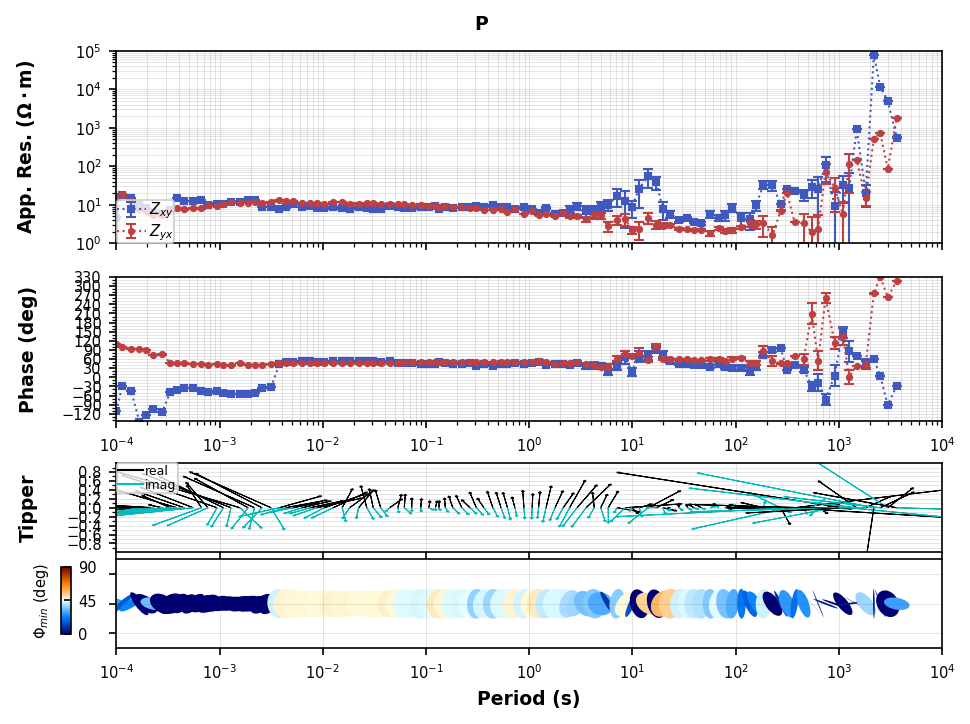

In [6]:
try:
    mc.plot_mt_response("P") # Nombre de la estación
except:
    pass

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 5 · Análisis de la distribución de frecuencias</span></div>

<div style="background:#f0f9ef;border-left:5px solid #27AE60;padding:10px 14px;border-radius:4px;margin:6px 0">Distintos equipos MT registran diferentes rangos de frecuencias. Antes de interpolar o procesar en conjunto todos los sondeos, es fundamental entender qué frecuencias tiene cada uno. Un <b>diagrama frecuencia-estación</b> permite identificar: brechas de frecuencia, inconsistencias entre equipos y el rango común para interpolación.</div>

 Convertimos la colección a MTData para acceder fácilmente a los IDs.

In [7]:
# Convertir a MTData
with MTCollection() as mc:
    mc.open_collection(Path("h5/"+"collection_crudo.h5"))  # Ruta para guardar el h5 crudo
    mtd = mc.to_mt_data()

26:03:17T15:23:14 | INFO | line:777 |mth5.mth5 | close_mth5 | Flushing and closing h5\collection_crudo.h5


Obtenemos las frecuencias registradas por cada uno de los sondeos.

In [8]:
# Obtener las frecuencias de cada sondeo

import numpy as np
frecuencias = []
for station in mc.make_file_list(edi_path, file_types=["edi"]):
    mt_object = MT(station) # Crea un objeto MT de cada edi
    mt_object.read() # Lee el objeto
    frecuencias.extend(1 / mt_object.Z.period)  # Convertir periodos a frecuencias

# Convertir a un array de numpy para mayor eficiencia
frecuencias = np.array(frecuencias)
print(frecuencias.shape)

26:03:17T15:23:14 | WARNING | line:668 |mt_metadata.transfer_functions.io.edi.edi | _read_spectra | spectral matrix determinant is too small 6.695516409475982e-18 for period 10000.0. Results may be inaccurate
26:03:17T15:23:14 | WARNING | line:668 |mt_metadata.transfer_functions.io.edi.edi | _read_spectra | spectral matrix determinant is too small 2.4126740561900087e-17 for period 8800.0. Results may be inaccurate
26:03:17T15:23:14 | WARNING | line:668 |mt_metadata.transfer_functions.io.edi.edi | _read_spectra | spectral matrix determinant is too small 1.182369536880004e-17 for period 7200.0. Results may be inaccurate
26:03:17T15:23:14 | WARNING | line:668 |mt_metadata.transfer_functions.io.edi.edi | _read_spectra | spectral matrix determinant is too small 3.875674150200011e-17 for period 4400.0. Results may be inaccurate
26:03:17T15:23:14 | WARNING | line:668 |mt_metadata.transfer_functions.io.edi.edi | _read_spectra | spectral matrix determinant is too small 4.20838146610001e-17 for 

Calculamos el número de ocurrencia de las frecuencias de cada sondeo. Esto permite conocer el rango y distribución de las frecuencias de todos los sondeos. 

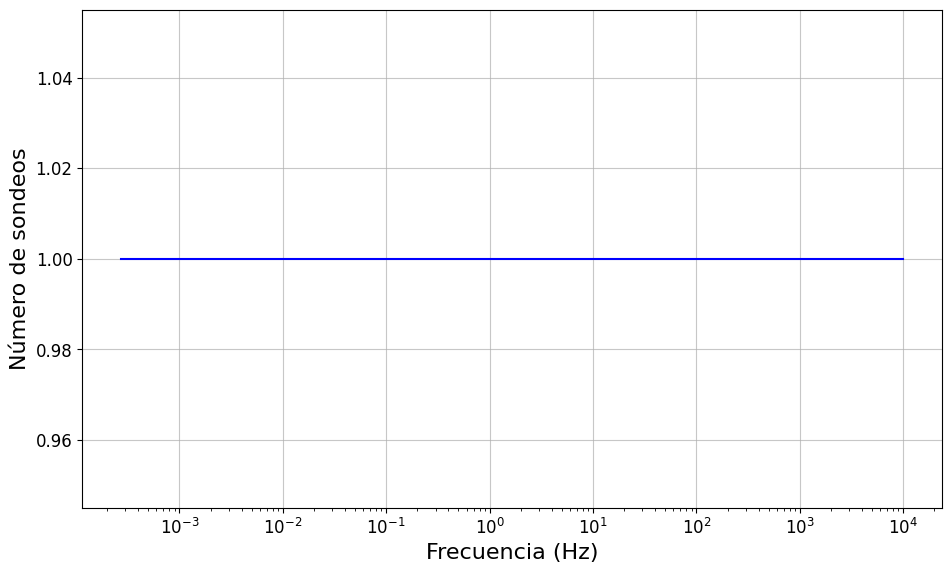

In [9]:
import os
# Definir el nombre de la carpeta y el archivo
folder_path = 'figuras'  # Carpeta donde quieres guardar la imagen
filename = "frecuen.png"  # Nombre del archivo

# Calcular el número de ocurrencia de las frecuencias de los sondeos

unique_freqs, counts = np.unique(frecuencias, return_counts=True)

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(unique_freqs, counts, linestyle="-", color="blue")
plt.xscale("log")
plt.xlabel("Frecuencia (Hz)", fontsize=16)
plt.ylabel("Número de sondeos", fontsize=16)
plt.grid(axis="both", linestyle="-", alpha=0.7)

# Cambiar tamaño de los números en los ejes
plt.tick_params(axis="x", labelsize=12)
plt.tick_params(axis="y", labelsize=12)

fig_path = os.path.join(folder_path, filename)
plt.savefig(fig_path, dpi=300, bbox_inches='tight', format="png")

plt.show()

In [10]:
# Calcular el valor mínimo y máximo de frecuencias de los sondeos
freq_min = np.min(frecuencias)
freq_max = np.max(frecuencias)

log_freq_min = np.log10(freq_min)
log_freq_max = np.log10(freq_max)

print(f"Frecuencia mínima: 10^{(log_freq_min):.1f} Hz")
print(f"Frecuencia máxima: 10^{(log_freq_max):.1f} Hz")

Frecuencia mínima: 10^-3.6 Hz
Frecuencia máxima: 10^4.0 Hz


In [11]:
# Obtener las frecuencias de cada sondeo

frecuencia = []
for station in mc.make_file_list(edi_path, file_types=["edi"]):
    mt_object = MT(station) # Crea un objeto MT de cada edi
    mt_object.read() # Lee el objeto
    frecuencia.append(1 / mt_object.Z.period)  # Convertir periodos a frecuencias
len(frecuencia)

26:03:17T15:23:16 | WARNING | line:668 |mt_metadata.transfer_functions.io.edi.edi | _read_spectra | spectral matrix determinant is too small 6.695516409475982e-18 for period 10000.0. Results may be inaccurate
26:03:17T15:23:16 | WARNING | line:668 |mt_metadata.transfer_functions.io.edi.edi | _read_spectra | spectral matrix determinant is too small 2.4126740561900087e-17 for period 8800.0. Results may be inaccurate
26:03:17T15:23:16 | WARNING | line:668 |mt_metadata.transfer_functions.io.edi.edi | _read_spectra | spectral matrix determinant is too small 1.182369536880004e-17 for period 7200.0. Results may be inaccurate
26:03:17T15:23:16 | WARNING | line:668 |mt_metadata.transfer_functions.io.edi.edi | _read_spectra | spectral matrix determinant is too small 3.875674150200011e-17 for period 4400.0. Results may be inaccurate
26:03:17T15:23:16 | WARNING | line:668 |mt_metadata.transfer_functions.io.edi.edi | _read_spectra | spectral matrix determinant is too small 4.20838146610001e-17 for 

1

In [12]:
estaciones =[]
for station_tf in mtd.mt_list:  
    station_id = station_tf.station 
    estaciones.append(station_id)

len(estaciones)

1

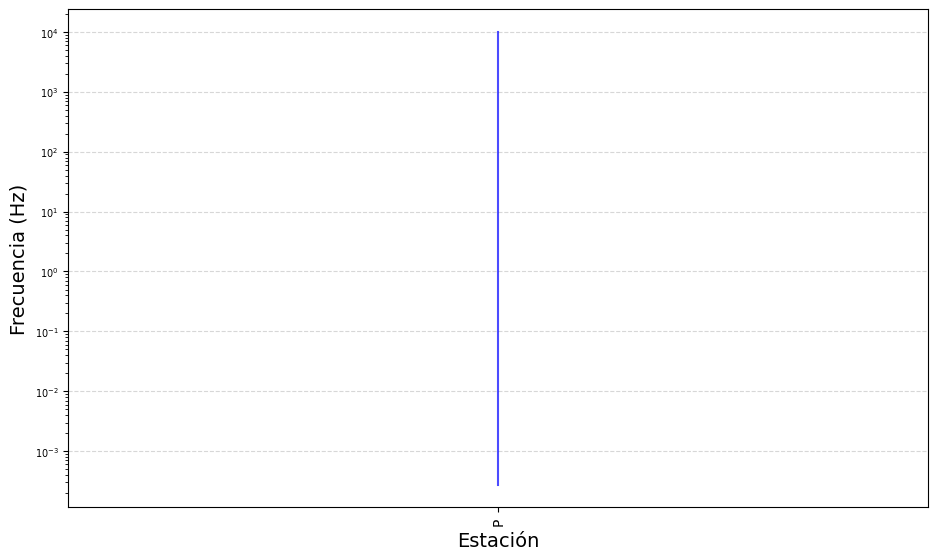

In [13]:
import os
# Definir el nombre de la carpeta y el archivo
folder_path = 'figuras'  # Carpeta donde quieres guardar la imagen
filename = "diagrama1.png"  # Nombre del archivo

plt.figure(figsize=(10, 6))

for idx, freqs in enumerate(frecuencia):  # Iterar sobre las frecuencias de cada estación
    station_id = estaciones[idx]       # Obtener el ID de la estación
    plt.plot([station_id] * len(freqs), freqs, '-', color="blue", alpha=0.7)  # Graficar cada frecuencia

plt.yscale("log")
plt.xlabel("Estación", fontsize=14)
plt.ylabel("Frecuencia (Hz)", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=90, fontsize=10)

fig_path = os.path.join(folder_path, filename)
plt.savefig(fig_path, dpi=300, bbox_inches='tight', format="png")
plt.show()

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷🔷 7 · Cerrar la colección</span></div>

<div style="background:#fef9e7;border-left:5px solid #F39C12;padding:10px 14px;border-radius:4px;margin:6px 0">⚠️ <b>Advertencia:</b> Siempre cierra el MTCollection al finalizar. No hacerlo puede corromper el archivo H5, ya que HDF5 necesita escribir metadatos al cerrarse correctamente.</div>

In [14]:
mc.close_collection() # Es importante siempre cerrar la colección para evitar daños en el archivo

26:03:17T15:23:18 | WARNING | line:330 |mth5.mth5 | filename | MTH5 file is not open or has not been created yet. Returning default name
26:03:17T15:23:18 | INFO | line:777 |mth5.mth5 | close_mth5 | Flushing and closing h5\collection_crudo.h5
